# Claim C1 — individual redundancy certificates do not compose

The intuition this claim attacks is a natural one: test each judge, find the ones
that the rest of the panel can reproduce, and delete all of them.

That reasoning is wrong, and it is wrong for a structural reason. A certificate
for judge *i* is conditional on **every peer being present**. Two judges can each
be redundant *given the other*, and deleting both destroys information neither
was individually responsible for.

This notebook measures the size of that mistake on synthetic panels where the
right answer is known by construction, so the gap can be attributed to the logic
rather than to noise in a model.

Source: `experiments/experiment_e0_noncomposability.py` -> `results/e0_noncomposability.json`.

## What Claim C1 says, and how this notebook tests it

> **Claim C1 — Individual redundancy certificates do not compose.**
>
> *"Many judges may be individually reconstructable when all peers are present,
> yet removing all individually reconstructable judges at once can violate the
> target coverage tolerance."*
>
> — execution plan, §5

**In words.** Ask of each judge *i*: "if I delete only you, can the others rebuild
your probability vector to within $\gamma$?" Many judges pass. The mistake is to
conclude that they can therefore all go. Each pass was granted *on the assumption
that the whole rest of the panel stays*, so the certificates are not independent
statements and cannot be added up.

**Formally**, following plan §22 (Experiment E0), for each tolerance $\gamma$:

| symbol | meaning |
|---|---|
| $U(i \mid \mathcal{J}\setminus\{i\})$ | leave-one-out error: the best worst-context TV with which the other $N-1$ judges reconstruct judge $i$ |
| $R_\gamma = \{i : U(i\mid \mathcal{J}\setminus\{i\}) \le \gamma\}$ | the **individually removable** set |
| $S^{\mathrm{naive}}_\gamma = \mathcal{J} \setminus R_\gamma$ | what the naive per-judge filter would keep |
| $E(S^{\mathrm{naive}}_\gamma)$ | the joint error that set actually achieves |
| **composition gap** | $\min\{|S| : E(S)\le\gamma\} \;-\; |S^{\mathrm{naive}}_\gamma|$ |

C1 holds when $E(S^{\mathrm{naive}}_\gamma) > \gamma$ and the composition gap is
strictly positive: the filter deleted judges it had no right to delete.

**Why it matters for everything after it.** If individual decisions *did* compose,
panel compression would be a sorting problem — score each judge once, keep the top
ones. C1 is what forces the search to range over *sets*, and it is therefore the
precondition for the joint optimisation that Claim C2 relies on.

**What would refute it.** A composition gap of zero across the tolerance grid and
all seeds. The plan (§22, *Failure interpretation*) is explicit that such a result
must be reported rather than hidden.

**Scope of this notebook.** The evidence here is on *synthetic* panels, whose
correct answer is fixed by the geometry of the construction, so any gap is
attributable to the reasoning rather than to noise in a language model. The
real-judge replication of E0 belongs to the same gate sequence as C2 (see
notebook 03).

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)
FIGS = os.path.join(ROOT, "results", "figures")
os.makedirs(FIGS, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})

with open(os.path.join(ROOT, "results", "e0_noncomposability.json")) as handle:
    e0 = json.load(handle)

records = e0["records"]
gammas = e0["gammas"]
instances = sorted({r["instance"] for r in records})
print(f"{len(records)} records | instances {instances} | seeds {e0['seeds']}")

60 records | instances ['curved_arc_9', 'duplicated_extremes'] | seeds [0, 1, 2, 3, 4]


## 1. The failure in its cleanest form

`duplicated_extremes` is a panel of three opinions, each held by two judges. Every
judge is *perfectly* reproducible by its twin, so leave-one-out marks all six as
removable. Delete all six and nothing is left.

In [2]:
dup = [r for r in records if r["instance"] == "duplicated_extremes"][0]

print(f"panel size                     {dup['n_judges']}")
print(f"leave-one-out errors           {dup['loo_errors']}")
print(f"individually removable         {dup['n_individually_removable']} of {dup['n_judges']}")
print(f"naive 'remove them all' keeps  {dup['naive_retained_size']}")
print(f"  -> resulting coverage        {dup['naive_coverage']}")
print(f"  -> violates the tolerance    {dup['naive_violates_gamma']}")
print(f"smallest set that actually works {dup['min_feasible_size']}  {dup['min_feasible_set']}")
print(f"composition gap                {dup['composition_gap']}")

panel size                     6
leave-one-out errors           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
individually removable         6 of 6
naive 'remove them all' keeps  0
  -> resulting coverage        inf
  -> violates the tolerance    True
smallest set that actually works 3  ['A_1', 'B_1', 'tie_1']
composition gap                3


Every judge is individually redundant, yet the smallest panel that meets the
tolerance has three members. The naive rule does not merely overshoot — it
returns the empty set and infinite error.

## 2. The gap across tolerances and instances

The composition gap is `min_feasible_size - naive_retained_size`: how many judges
the naive rule deletes that it had no right to delete.

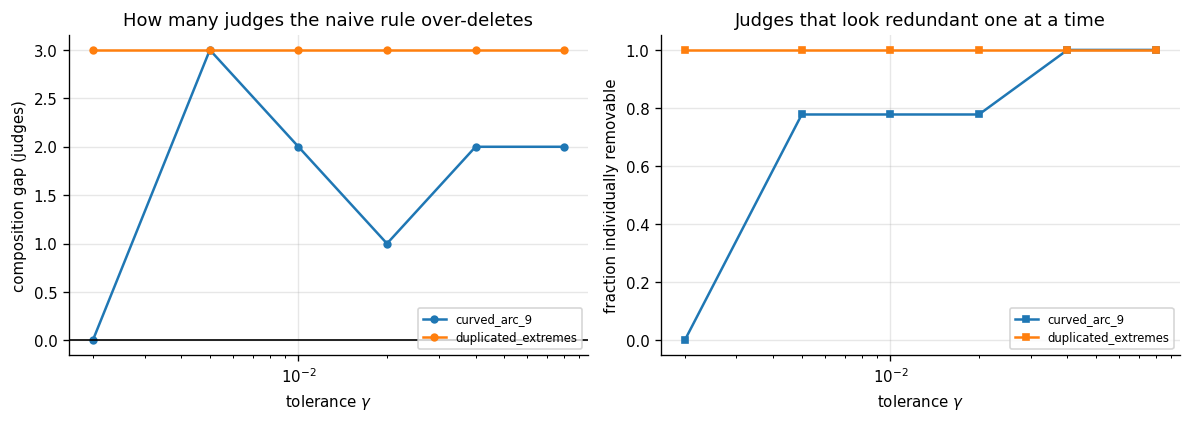

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

for inst in instances:
    rows = [r for r in records if r["instance"] == inst]
    gap_mean, gap_lo, gap_hi, frac = [], [], [], []
    for g in gammas:
        vals = [r["composition_gap"] for r in rows if r["gamma"] == g]
        fr = [r["frac_individually_removable"] for r in rows if r["gamma"] == g]
        gap_mean.append(np.mean(vals)); gap_lo.append(np.min(vals)); gap_hi.append(np.max(vals))
        frac.append(np.mean(fr))
    axes[0].plot(gammas, gap_mean, marker="o", ms=4, label=inst)
    axes[0].fill_between(gammas, gap_lo, gap_hi, alpha=0.15)
    axes[1].plot(gammas, frac, marker="s", ms=4, label=inst)

axes[0].axhline(0, color="k", lw=1)
axes[0].set_xscale("log"); axes[0].set_xlabel("tolerance $\\gamma$")
axes[0].set_ylabel("composition gap (judges)")
axes[0].set_title("How many judges the naive rule over-deletes")
axes[0].legend(fontsize=7)

axes[1].set_xscale("log"); axes[1].set_xlabel("tolerance $\\gamma$")
axes[1].set_ylabel("fraction individually removable")
axes[1].set_title("Judges that look redundant one at a time")
axes[1].legend(fontsize=7)

fig.tight_layout()
fig.savefig(os.path.join(FIGS, "c1_composition_gap.png"), bbox_inches="tight")

## 3. How often does the naive rule actually break the tolerance?

The gap is only worth reporting if the resulting panel is genuinely infeasible.

In [4]:
print(f"{'instance':<18}{'gamma':>8}{'removable':>11}{'naive |S|':>11}{'min |S|':>9}{'gap':>6}{'violates':>10}")
for inst in instances:
    for g in gammas:
        rows = [r for r in records if r["instance"] == inst and r["gamma"] == g]
        viol = np.mean([r["naive_violates_gamma"] for r in rows])
        print(f"{inst:<18}{g:>8}{np.mean([r['n_individually_removable'] for r in rows]):>11.1f}"
              f"{np.mean([r['naive_retained_size'] for r in rows]):>11.1f}"
              f"{np.mean([r['min_feasible_size'] for r in rows]):>9.1f}"
              f"{np.mean([r['composition_gap'] for r in rows]):>6.1f}{viol:>10.0%}")

overall = np.mean([r["naive_violates_gamma"] for r in records])
print(f"\nnaive rule violates the tolerance in {overall:.0%} of all {len(records)} instance-tolerance-seed cases")

instance             gamma  removable  naive |S|  min |S|   gap  violates
curved_arc_9         0.002        0.0        9.0      9.0   0.0        0%
curved_arc_9         0.005        7.0        2.0      5.0   3.0      100%
curved_arc_9          0.01        7.0        2.0      4.0   2.0      100%
curved_arc_9          0.02        7.0        2.0      3.0   1.0      100%
curved_arc_9          0.04        9.0        0.0      2.0   2.0      100%
curved_arc_9          0.08        9.0        0.0      2.0   2.0      100%
duplicated_extremes   0.002        6.0        0.0      3.0   3.0      100%
duplicated_extremes   0.005        6.0        0.0      3.0   3.0      100%
duplicated_extremes    0.01        6.0        0.0      3.0   3.0      100%
duplicated_extremes    0.02        6.0        0.0      3.0   3.0      100%
duplicated_extremes    0.04        6.0        0.0      3.0   3.0      100%
duplicated_extremes    0.08        6.0        0.0      3.0   3.0      100%

naive rule violates the toleran

## 4. Why it happens: mutual-dependency cycles

Draw an edge from *i* to *j* when *j* carries significant weight in the
certificate that justifies deleting *i*. A cycle is a group of judges each of
whom is only redundant *because the others are present* — exactly the set the
naive rule deletes wholesale.

duplicated_extremes cycles: [[0, 1], [2, 3], [4, 5]]
each pair is a twin that certifies its own removal


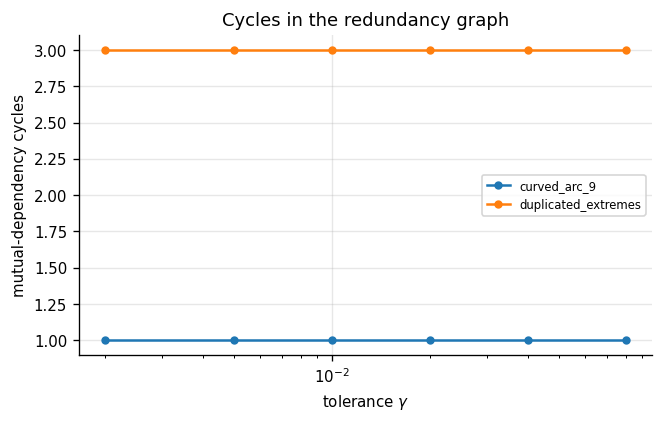

In [5]:
fig, ax = plt.subplots(figsize=(5.6, 3.6))
for inst in instances:
    rows = [r for r in records if r["instance"] == inst]
    y = [np.mean([r["dependency_graph"]["n_cycles"] for r in rows if r["gamma"] == g])
         for g in gammas]
    ax.plot(gammas, y, marker="o", ms=4, label=inst)
ax.set_xscale("log"); ax.set_xlabel("tolerance $\\gamma$")
ax.set_ylabel("mutual-dependency cycles")
ax.set_title("Cycles in the redundancy graph")
ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "c1_dependency_cycles.png"), bbox_inches="tight")

print("duplicated_extremes cycles:", dup["dependency_graph"]["cycles"])
print("each pair is a twin that certifies its own removal")

## 5. The same test on the real Core-8 judges

Plan §22 step 8 asks for the procedure to be repeated across the five grouped
split seeds, and the sections above satisfy that only on the synthetic panels.
Below is the identical analysis on the **scored Core-8 tensor**, fitted on FIT and
judged on CERT, with TEST left locked for E1.

Only the FIT/CERT/TEST *partition* changes between the five seeds — all five
split files partition the same 1865 base items, so re-splitting costs no GPU time.
That is a property worth knowing before booking the server, and it is pinned by
`tests/test_panel_split_seeds.py`.

Source: `experiments/experiment_e0_noncomposability.py --real` ->
`results/e0_real_core8.json`.

leave-one-out error U(i | J\{i}) on CERT, mean over 5 split seeds
   judge     mean     min     max
     J02    0.624   0.571   0.718
     J05    0.400   0.347   0.446
     J08    0.256   0.241   0.292
     J10    0.459   0.417   0.512
     J12    0.377   0.341   0.407
     J14    0.588   0.554   0.629
     J16    0.330   0.310   0.350
     J20    0.273   0.242   0.289

smallest LOO error anywhere: 0.241
largest declared tolerance:  0.200
-> judges individually removable at any declared gamma: 0


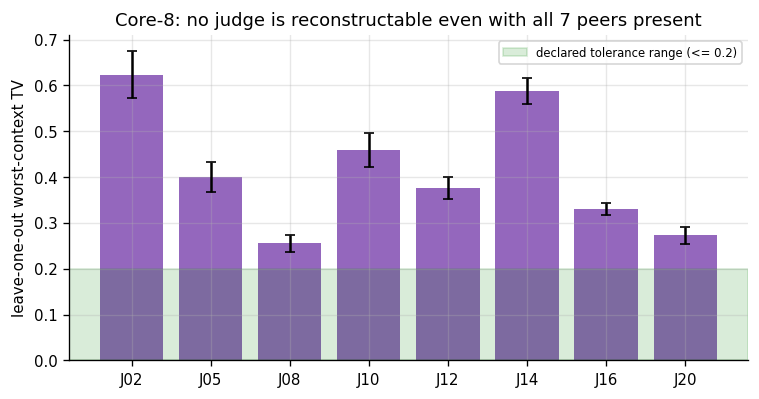

In [6]:
real_path = os.path.join(ROOT, "results", "e0_real_core8.json")
real = json.load(open(real_path))
rrec = real["records"]
rjudges = json.load(open(os.path.join(ROOT, "results", "e1_frontier.json")))["judges"]

loo = np.array([r["loo_errors"] for r in rrec])          # (rows, n_judges)
per_judge = loo.reshape(len(real["split_seeds"]), len(real["gammas"]), -1)[:, 0, :]

print(f"leave-one-out error U(i | J\\{{i}}) on CERT, mean over {len(real['split_seeds'])} split seeds")
print(f"{'judge':>8}{'mean':>9}{'min':>8}{'max':>8}")
for i, j in enumerate(rjudges):
    col = per_judge[:, i]
    print(f"{j:>8}{col.mean():>9.3f}{col.min():>8.3f}{col.max():>8.3f}")

print(f"\nsmallest LOO error anywhere: {loo.min():.3f}")
print(f"largest declared tolerance:  {max(real['gammas']):.3f}")
print(f"-> judges individually removable at any declared gamma: "
      f"{sum(r['n_individually_removable'] for r in rrec)}")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.bar(range(len(rjudges)), per_judge.mean(axis=0),
       yerr=per_judge.std(axis=0), color="tab:purple", capsize=3)
ax.axhspan(0, max(real["gammas"]), color="green", alpha=0.15,
           label=f"declared tolerance range (<= {max(real['gammas'])})")
ax.set_xticks(range(len(rjudges))); ax.set_xticklabels(rjudges)
ax.set_ylabel("leave-one-out worst-context TV")
ax.set_title("Core-8: no judge is reconstructable even with all 7 peers present")
ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "c1_real_loo.png"), bbox_inches="tight")

## Verdict on C1

**Supported on the controlled constructions, and untestable on Core-8.**

On the synthetic panels, where the right answer is known by construction:

* on `duplicated_extremes` all judges are individually removable, yet removing
  them together leaves the empty panel and unbounded error;
* the composition gap is strictly positive across the tolerance grid and seeds; and
* the redundancy graph contains cycles, which is the mechanism — mutual
  redundancy is not individual redundancy.

This is what forces selection to be a joint combinatorial problem rather than a
per-judge filter, and it is the reason the rest of the project searches over sets
instead of ranking judges.

**On the real Core-8 panel the claim cannot be posed at all.** Section 5 shows the
smallest leave-one-out error over every judge and every split seed is ≈ 0.24,
while the largest declared tolerance is 0.20. So $R_\gamma = \varnothing$ at every
$\gamma$: *no* judge is individually removable, $S^{\mathrm{naive}}_\gamma$ is the
whole panel, and the composition gap is trivially 0. C1 is a statement about what
happens when many judges pass the individual test, and on Core-8 none do.

That is a null result about the *panel*, not about the claim, and it is the same
underlying fact that flattens the C2 frontier in notebook 03: eight deliberately
heterogeneous judges carry almost no mutual redundancy. Confirming C1 on real
models needs Core-20, where within-family pairs (Qwen 2.5 at 3B/7B/14B, Qwen 3 at
4B/8B/14B, Phi at three scales, two Mistrals, two Falcons) are exactly the
structure the claim is about — and exactly the structure Core-8 was built to
exclude.

**Not yet done for C1:** the real-panel replication above is reported honestly but
is uninformative until the panel is larger. Everything else in §22 is complete.